In [5]:
import pandas as pd
from pathlib import Path

# Define the base directory
base_dir = Path(r"C:\Users\31616\Desktop\mdte-dt5\jupyter-notebook\data-collection\data")

# Empty list to store each file’s dataframe
all_data = []
file_counter = 0

# Iterate through all folders and files
for folder in base_dir.glob("test_*"):
    if folder.is_dir():
        for file in folder.glob("*.csv"):
            try:
                # Read each CSV safely
                df = pd.read_csv(file)
                
                # Skip empty files
                if df.empty:
                    print(f"⚠️ Skipped empty file: {file}")
                    continue
                
                # Add folder and file identifiers
                df["main_folder"] = folder.name
                df["file_name"] = file.stem  # name without .csv for easier handling
                
                # Add to list
                all_data.append(df)
                file_counter += 1
                
            except Exception as e:
                print(f"❌ Error reading {file}: {e}")

# Combine all dataframes into one
if all_data:
    combined_data = pd.concat(all_data, ignore_index=True)
    combined_data.to_csv(base_dir / "combined_sensor_data.csv", index=False)
    
    print("\n✅ Data successfully combined!")
    print(f"📁 Total folders processed: {len(list(base_dir.glob('test_*')))}")
    print(f"📄 Total CSV files processed: {file_counter}")
    print(f"🧩 Combined data shape: {combined_data.shape}\n")
    print(combined_data[["main_folder", "file_name"]].head())
else:
    print("⚠️ No valid CSV files found.")



✅ Data successfully combined!
📁 Total folders processed: 6
📄 Total CSV files processed: 200
🧩 Combined data shape: (24900, 11)

       main_folder                        file_name
0  test_1_20251024  test_1_falling_10_124samples_5s
1  test_1_20251024  test_1_falling_10_124samples_5s
2  test_1_20251024  test_1_falling_10_124samples_5s
3  test_1_20251024  test_1_falling_10_124samples_5s
4  test_1_20251024  test_1_falling_10_124samples_5s


In [6]:
combined_data.head(10)

,t,acc_x,acc_y,acc_z,gyro_x,gyro_y,gyro_z,dt,dt_sec,main_folder,file_name
0,820080142.0,-0.121,1.934,-0.135,6.140,30.455,8.598,36990.0,0.036990,test_1_20251024,test_1_falling_10_124samples_5s
1,820116955.0,-0.179,1.897,-0.218,17.126,17.638,10.246,36813.0,0.036813,test_1_20251024,test_1_falling_10_124samples_5s
2,820167892.0,-0.068,2.293,-0.048,8.398,35.826,6.645,50937.0,0.050937,test_1_20251024,test_1_falling_10_124samples_5s
3,820204897.0,0.051,2.308,-0.146,3.332,46.141,8.171,37005.0,0.037005,test_1_20251024,test_1_falling_10_124samples_5s
4,820241885.0,-0.273,2.197,-0.239,24.633,46.569,11.589,36988.0,0.036988,test_1_20251024,test_1_falling_10_124samples_5s
5,820278866.0,-0.427,2.080,-0.342,22.314,6.163,4.082,36981.0,0.036981,test_1_20251024,test_1_falling_10_124samples_5s
6,820329773.0,0.085,2.075,-0.683,22.070,10.863,8.354,50907.0,0.050907,test_1_20251024,test_1_falling_10_124samples_5s
7,820366733.0,0.044,2.019,-0.691,1.745,11.840,15.800,36960.0,0.036960,test_1_20251024,test_1_falling_10_124samples_5s
8,820403698.0,0.036,1.804,-0.532,-8.570,-4.579,6.401,36965.0,0.036965,test_1_20251024,test_1_falling_10_124samples_5s
9,820439764.0,-0.014,1.878,-0.454,-1.245,-10.316,7.256,36066.0,0.036066,test_1_20251024,test_1_falling_10_124samples_5s


In [7]:
import pandas as pd
import numpy as np
from tqdm import tqdm

# TSFresh (minimal example)
from tsfresh.feature_extraction import extract_features, EfficientFCParameters, MinimalFCParameters
from tsfresh.utilities.dataframe_functions import impute

In [8]:
TARGET_FREQ_HZ = 25  # target resample frequency
WINDOW_SECONDS = 2.0  # window length for feature extraction (seconds)
OVERLAP = 0.5  # 50% overlap

In [9]:
df = combined_data.copy()

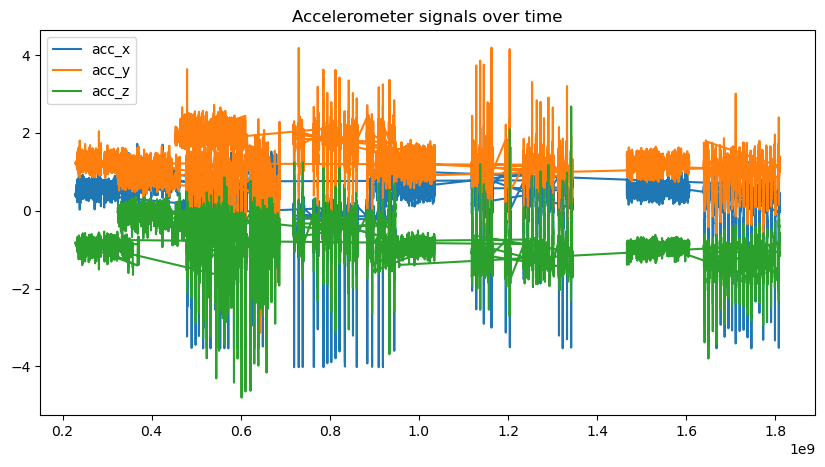

In [10]:
import matplotlib.pyplot as plt

# Plot acceleration over time
plt.figure(figsize=(10,5))
plt.plot(df['t'], df['acc_x'], label='acc_x')
plt.plot(df['t'], df['acc_y'], label='acc_y')
plt.plot(df['t'], df['acc_z'], label='acc_z')
plt.legend()
plt.title("Accelerometer signals over time")
plt.show()

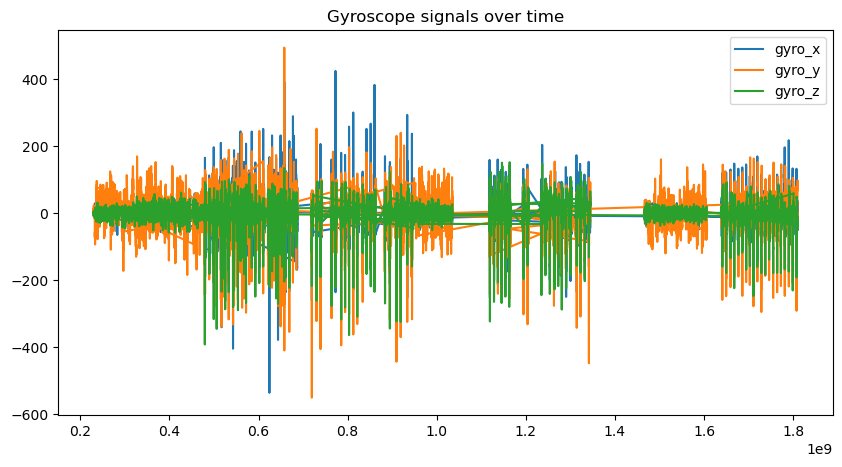

In [11]:
# Plot gyroscope signals
plt.figure(figsize=(10,5))
plt.plot(df['t'], df['gyro_x'], label='gyro_x')
plt.plot(df['t'], df['gyro_y'], label='gyro_y')
plt.plot(df['t'], df['gyro_z'], label='gyro_z')
plt.legend()
plt.title("Gyroscope signals over time")
plt.show()

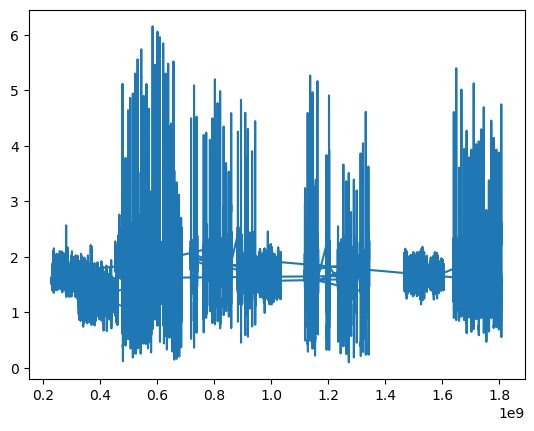

In [12]:
df['acc_mag'] = (df['acc_x']**2 + df['acc_y']**2 + df['acc_z']**2)**0.5
plt.plot(df['t'], df['acc_mag'])


In [13]:
import pandas as pd

# Example: assuming your DataFrame is called df
# Create a new column 'activity' by checking keywords in 'file_name'
df['activity'] = df['file_name'].apply(
    lambda x: 'fall' if 'fall' in x.lower() else
              ('walk' if 'walk' in x.lower() else 'other')
)

# Optional: check how many samples per activity type
print(df['activity'].value_counts())


activity
walk    12465
fall    12435
Name: count, dtype: int64


In [16]:
df.head(10)

,t,acc_x,acc_y,acc_z,gyro_x,gyro_y,gyro_z,dt,dt_sec,main_folder,file_name,acc_mag,activity
0,820080142.0,-0.121,1.934,-0.135,6.140,30.455,8.598,36990.0,0.036990,test_1_20251024,test_1_falling_10_124samples_5s,1.942478,fall
1,820116955.0,-0.179,1.897,-0.218,17.126,17.638,10.246,36813.0,0.036813,test_1_20251024,test_1_falling_10_124samples_5s,1.917857,fall
2,820167892.0,-0.068,2.293,-0.048,8.398,35.826,6.645,50937.0,0.050937,test_1_20251024,test_1_falling_10_124samples_5s,2.294510,fall
3,820204897.0,0.051,2.308,-0.146,3.332,46.141,8.171,37005.0,0.037005,test_1_20251024,test_1_falling_10_124samples_5s,2.313176,fall
4,820241885.0,-0.273,2.197,-0.239,24.633,46.569,11.589,36988.0,0.036988,test_1_20251024,test_1_falling_10_124samples_5s,2.226760,fall
5,820278866.0,-0.427,2.080,-0.342,22.314,6.163,4.082,36981.0,0.036981,test_1_20251024,test_1_falling_10_124samples_5s,2.150742,fall
6,820329773.0,0.085,2.075,-0.683,22.070,10.863,8.354,50907.0,0.050907,test_1_20251024,test_1_falling_10_124samples_5s,2.186170,fall
7,820366733.0,0.044,2.019,-0.691,1.745,11.840,15.800,36960.0,0.036960,test_1_20251024,test_1_falling_10_124samples_5s,2.134427,fall
8,820403698.0,0.036,1.804,-0.532,-8.570,-4.579,6.401,36965.0,0.036965,test_1_20251024,test_1_falling_10_124samples_5s,1.881153,fall
9,820439764.0,-0.014,1.878,-0.454,-1.245,-10.316,7.256,36066.0,0.036066,test_1_20251024,test_1_falling_10_124samples_5s,1.932148,fall


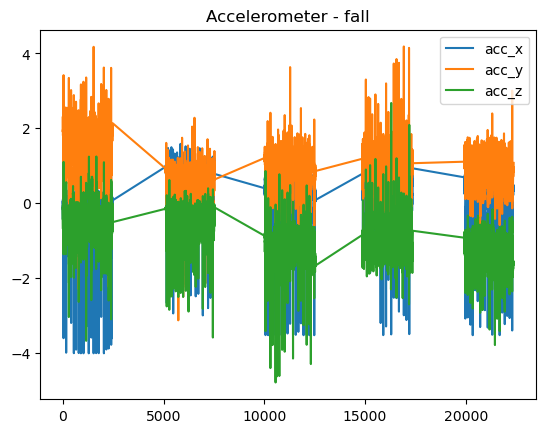

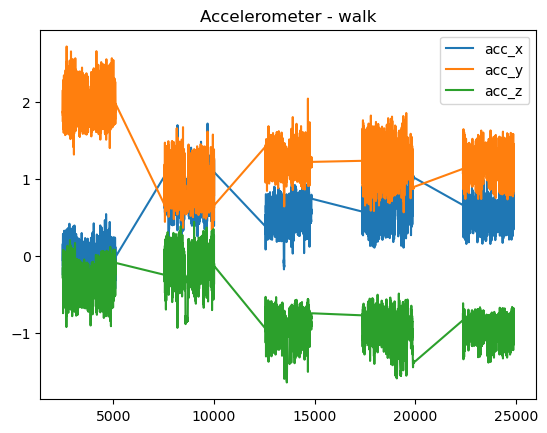

In [17]:
for activity in df['activity'].unique():
    subset = df[df['activity'] == activity]
    subset[['acc_x', 'acc_y', 'acc_z']].plot(title=f"Accelerometer - {activity}")
